In [1]:
from google.colab import files
uploaded = files.upload()

Saving mao_a_ic50.csv to mao_a_ic50 (1).csv
Saving mao_b_ic50.csv to mao_b_ic50 (1).csv
Saving AChE_Bioactivity_data_2.csv to AChE_Bioactivity_data_2 (1).csv


In [2]:
!pip install pandas matplotlib seaborn rdkit scikit-learn tensorflow datasets scikit-learn pandas numpy transformers

In [11]:
import subprocess
import time
import requests
import os
import threading
import json

print("Installing Ollama in Google Colab...")
!curl -fsSL https://ollama.ai/install.sh | sh

def run_ollama_server():
    """Run Ollama server in background"""
    try:
        subprocess.run(['pkill', '-f', 'ollama'], check=False)
        time.sleep(2)
    except:
        pass


    env = os.environ.copy()
    env['OLLAMA_NUM_PARALLEL'] = '1'
    env['OLLAMA_MAX_LOADED_MODELS'] = '1'

    process = subprocess.Popen(
        ['ollama', 'serve'],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        universal_newlines=True,
        env=env
    )
    return process

print("Starting Ollama server...")
ollama_process = run_ollama_server()


for i in range(6):
    time.sleep(5)
    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=5)
        if response.status_code == 200:
            print(f"Ollama server ready after {(i+1)*5} seconds!")
            break
    except:
        if i == 5:
            print("Server taking longer than expected to start...")
        continue


try:
    response = requests.get("http://localhost:11434/api/tags", timeout=10)
    if response.status_code == 200:
        print("Ollama server is running!")
    else:
        print(f"Ollama server status: {response.status_code}")
except Exception as e:
    print(f"Ollama server check failed: {e}")

print("Downloading TinyLlama model...")
!ollama pull tinyllama

print("Model downloaded successfully!")
!ollama list

def test_ollama_connection():
    """Test if Ollama is working with the correct model"""
    print("Testing basic server connectivity...")


    try:
        response = requests.get("http://localhost:11434/api/tags", timeout=10)
        if response.status_code != 200:
            print(f"Server not responding properly: {response.status_code}")
            return False
        print("✓ Server is responding")
    except Exception as e:
        print(f"✗ Server connectivity failed: {e}")
        return False

    try:
        print("Testing model inference with simple prompt...")
        data = {
            "model": "tinyllama",
            "prompt": "Hi",
            "stream": False,
            "options": {
                "num_predict": 10,
                "temperature": 0.1,
                "top_p": 0.9
            }
        }

        response = requests.post(
            "http://localhost:11434/api/generate",
            json=data,
            timeout=120
        )

        if response.status_code == 200:
            result = response.json()
            print("✓ Ollama test successful!")
            print("Response:", result.get('response', 'No response'))
            return True
        else:
            print(f"✗ Ollama test failed: {response.status_code}")
            print("Response text:", response.text)
            return False

    except requests.exceptions.Timeout:
        print("✗ Model inference timed out - this is common in Colab")
        print("The model might be too slow for this environment")
        return False
    except Exception as e:
        print(f"✗ Ollama test error: {e}")
        return False


test_ollama_connection()


def list_available_models():
    """List all available models"""
    try:
        response = requests.get("http://localhost:11434/api/tags")
        if response.status_code == 200:
            models = response.json()
            print("Available models:")
            for model in models.get('models', []):
                print(f"- {model['name']}")
        else:
            print(f"Failed to list models: {response.status_code}")
    except Exception as e:
        print(f"Error listing models: {e}")

list_available_models()

def chat_with_ollama(prompt, model="tinyllama", max_tokens=50):
    """Chat with Ollama model with optimizations for Colab"""
    try:
        data = {
            "model": model,
            "prompt": prompt,
            "stream": False,
            "options": {
                "num_predict": max_tokens,
                "temperature": 0.7,
                "top_p": 0.9,
                "num_ctx": 1024
            }
        }

        print(f"Sending request to model...")
        response = requests.post(
            "http://localhost:11434/api/generate",
            json=data,
            timeout=180
        )

        if response.status_code == 200:
            result = response.json()
            return result.get('response', 'No response received')
        else:
            return f"Error: {response.status_code} - {response.text}"

    except requests.exceptions.Timeout:
        return "Request timed out - model may be too slow for this environment"
    except Exception as e:
        return f"Error: {e}"

def chat_with_ollama_stream(prompt, model="tinyllama"):
    """Chat with Ollama using streaming for better responsiveness"""
    try:
        data = {
            "model": model,
            "prompt": prompt,
            "stream": True,
            "options": {
                "num_predict": 100,
                "temperature": 0.7
            }
        }

        response = requests.post(
            "http://localhost:11434/api/generate",
            json=data,
            stream=True,
            timeout=30
        )

        if response.status_code == 200:
            full_response = ""
            print("Streaming response:")
            for line in response.iter_lines():
                if line:
                    try:
                        chunk = json.loads(line)
                        if 'response' in chunk:
                            print(chunk['response'], end='', flush=True)
                            full_response += chunk['response']
                        if chunk.get('done', False):
                            break
                    except json.JSONDecodeError:
                        continue
            print()  # New line
            return full_response
        else:
            return f"Error: {response.status_code}"

    except Exception as e:
        return f"Error: {e}"

print("\nTesting chat functionality:")
response = chat_with_ollama("What is Python programming?")
print("AI Response:", response)

Installing Ollama in Google Colab...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Starting Ollama server...
Ollama server ready after 5 seconds!
Ollama server is running!

Model downloaded successfully!
NAME                ID              SIZE      MODIFIED               
tinyllama:latest    2644915ede35    637 MB    Less than a second ago    
Testing basic server connectivity...
✓ Server is responding
Testing model inference with simple prompt...
✓ Ollama test successful!
Response: Absolutely! Here's an updated version
Available models:
- tinyllama:latest

Testing chat functionality:
Sending requ

In [14]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
import requests
import json
import time
from sklearn.metrics import r2_score, accuracy_score, classification_report
import re
import warnings
warnings.filterwarnings('ignore')

class ColabLLMMolecularPredictor:
    def __init__(self, model_name="tinyllama"):
        self.model_name = model_name
        self.ollama_url = "http://localhost:11434/api/generate"

    def create_sample_data(self):
        """Create sample molecular data"""
        sample_smiles = [
            "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # Ibuprofen
            "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",    # Caffeine
            "CC(=O)OC1=CC=CC=C1C(=O)O",        # Aspirin
            "CCN(CC)CCNC1=C2C=CC(=CC2=NC=C1)Cl", # Chloroquine-like
            "CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F",
            "COC1=CC=C(C=C1)CCN2CCC(CC2)C3=NOC4=C3C=CC(=C4)F",
            "CN1CCN(CC1)C2=C(C=C(C=C2)Cl)C(=O)N3CCN(CC3)C",
            "CC1=CC(=C(C=C1C)O)C(=O)NCCC2=CC=C(C=C2)O",
            "CCOC(=O)C1=CN=C(C=C1)C2=CC=CC=N2",
            "CC(C)(C)NCC(C1=CC(=C(C=C1)O)CO)O"
        ]

        np.random.seed(42)
        data = []

        for i in range(100):
            smiles = np.random.choice(sample_smiles)
            target = np.random.choice(['MAO-A', 'MAO-B', 'AChE'])


            if target == 'MAO-A':
                ic50 = np.random.lognormal(4.2, 1.2) * 1000
            elif target == 'MAO-B':
                ic50 = np.random.lognormal(3.8, 1.4) * 1000
            else:  # AChE
                ic50 = np.random.lognormal(4.5, 1.1) * 1000

            data.append({
                'canonical_smiles': smiles,
                'standard_value': ic50,
                'target': target
            })

        df = pd.DataFrame(data)
        df['log_ic50'] = np.log10(df['standard_value'])
        df['activity_class'] = (df['log_ic50'] < 5).astype(int)

        return df

    def get_molecular_description(self, smiles):
        """Get molecular description for LLM"""
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return f"Invalid molecule: {smiles}"

            mw = Descriptors.MolWt(mol)
            logp = Descriptors.MolLogP(mol)
            hbd = Descriptors.NumHDonors(mol)
            hba = Descriptors.NumHAcceptors(mol)
            tpsa = Descriptors.TPSA(mol)

            return f"Molecular Weight: {mw:.1f} Da, LogP: {logp:.2f}, H-bond donors: {hbd}, H-bond acceptors: {hba}, Polar surface area: {tpsa:.1f}, SMILES: {smiles}"
        except:
            return f"SMILES: {smiles}"

    def create_llm_prompt(self, smiles, target, task_type="classification"):
        """Create optimized prompts for Llama"""
        mol_desc = self.get_molecular_description(smiles)

        if task_type == "classification":
            prompt = f"""You are a medicinal chemist. Predict if this molecule will be ACTIVE or INACTIVE against {target} enzyme.

Molecule: {mol_desc}

Context: {target} is important for Alzheimer's disease. Active compounds have IC50 < 100,000 nM.

Consider:
- Molecular weight (optimal: 150-500 Da)
- LogP (optimal: 0-5 for brain penetration)
- Polar surface area (optimal: <90 Å² for BBB)
- Structural features for {target} binding

Answer with just: ACTIVE or INACTIVE"""

        else:
            prompt = f"""You are a medicinal chemist. Predict the log IC50 value (scale 3-8) for this molecule against {target}.

Molecule: {mol_desc}

Context: {target} enzyme inhibition for Alzheimer's. Lower log IC50 = more potent.
- log IC50 3-4: Very potent
- log IC50 4-5: Potent
- log IC50 5-6: Moderate
- log IC50 6-8: Weak

Answer with just a number between 3 and 8."""

        return prompt

    def query_ollama(self, prompt):
        """Query Ollama with error handling"""
        try:
            data = {
                "model": self.model_name,
                "prompt": prompt,
                "stream": False,
                "options": {
                    "temperature": 0.3,
                    "top_p": 0.9,
                    "max_tokens": 100
                }
            }

            response = requests.post(self.ollama_url, json=data, timeout=60)

            if response.status_code == 200:
                result = response.json()
                return result.get('response', '').strip()
            else:
                print(f"Ollama error: {response.status_code}")
                return None

        except Exception as e:
            print(f"Ollama query error: {e}")
            return None

    def parse_response(self, response, task_type="classification"):
        """Parse LLM response"""
        if not response:
            return None

        response = response.upper().strip()

        if task_type == "classification":
            if "ACTIVE" in response and "INACTIVE" not in response:
                return 1
            elif "INACTIVE" in response:
                return 0
            else:
                return None
        else:

            numbers = re.findall(r'\d+\.?\d*', response)
            if numbers:
                try:
                    pred = float(numbers[0])
                    return max(3, min(8, pred))
                except:
                    return None
            return None

    def run_predictions(self, df, sample_size=20):
        """Run LLM predictions"""
        print(f"Running Llama predictions on {sample_size} molecules...")

        sample_df = df.sample(min(sample_size, len(df)), random_state=42)

        results = []

        for idx, row in sample_df.iterrows():
            print(f"Processing {len(results)+1}/{len(sample_df)}: {row['target']}")


            cls_prompt = self.create_llm_prompt(row['canonical_smiles'], row['target'], "classification")
            cls_response = self.query_ollama(cls_prompt)
            cls_pred = self.parse_response(cls_response, "classification")


            reg_prompt = self.create_llm_prompt(row['canonical_smiles'], row['target'], "regression")
            reg_response = self.query_ollama(reg_prompt)
            reg_pred = self.parse_response(reg_response, "regression")

            results.append({
                'smiles': row['canonical_smiles'],
                'target': row['target'],
                'true_class': row['activity_class'],
                'true_reg': row['log_ic50'],
                'pred_class': cls_pred,
                'pred_reg': reg_pred,
                'cls_response': cls_response,
                'reg_response': reg_response
            })

            time.sleep(1)

        return pd.DataFrame(results)

    def evaluate_results(self, results_df):
        """Evaluate and display results"""
        print("\n" + "="*50)
        print("LLAMA MOLECULAR PREDICTION RESULTS")
        print("="*50)


        valid_cls = results_df.dropna(subset=['pred_class'])
        if len(valid_cls) > 0:
            accuracy = accuracy_score(valid_cls['true_class'], valid_cls['pred_class'])
            print(f"\nCLASSIFICATION RESULTS:")
            print(f"Valid predictions: {len(valid_cls)}/{len(results_df)}")
            print(f"Accuracy: {accuracy:.3f}")

            print(f"\nDetailed Classification Report:")
            print(classification_report(valid_cls['true_class'], valid_cls['pred_class'],
                                      target_names=['Inactive', 'Active']))


        valid_reg = results_df.dropna(subset=['pred_reg'])
        if len(valid_reg) > 0:
            r2 = r2_score(valid_reg['true_reg'], valid_reg['pred_reg'])
            mae = np.mean(np.abs(valid_reg['true_reg'] - valid_reg['pred_reg']))

            print(f"\n📈 REGRESSION RESULTS:")
            print(f"Valid predictions: {len(valid_reg)}/{len(results_df)}")
            print(f"R² Score: {r2:.3f}")
            print(f"Mean Absolute Error: {mae:.3f}")

        print(f"\n🔍 EXAMPLE PREDICTIONS:")
        for i, row in results_df.head(3).iterrows():
            print(f"\nMolecule {i+1}:")
            print(f"Target: {row['target']}")
            print(f"True: Active={row['true_class']}, logIC50={row['true_reg']:.2f}")
            print(f"Predicted: Active={row['pred_class']}, logIC50={row['pred_reg']}")
            print(f"LLM Response: {row['cls_response'][:100]}...")

In [15]:
predictor = ColabLLMMolecularPredictor()


print("Creating sample molecular data...")
df = predictor.create_sample_data()

print(f"Dataset created:")
print(f"Total molecules: {len(df)}")
print(f"Targets: {df['target'].value_counts().to_dict()}")
print(f"Active molecules: {df['activity_class'].sum()}/{len(df)}")


results_df = predictor.run_predictions(df, sample_size=15)


predictor.evaluate_results(results_df)

print(f"\nAnalysis complete! Llama successfully analyzed molecular activity.")
print(f"Try increasing sample_size for more comprehensive results.")

Creating sample molecular data...
Dataset created:
Total molecules: 100
Targets: {np.str_('MAO-A'): 39, np.str_('AChE'): 34, np.str_('MAO-B'): 27}
Active molecules: 68/100
Running Llama predictions on 15 molecules...
Processing 1/15: AChE
Processing 2/15: MAO-A
Processing 3/15: AChE
Processing 4/15: MAO-A
Processing 5/15: MAO-B
Processing 6/15: AChE
Processing 7/15: MAO-A
Processing 8/15: MAO-B
Processing 9/15: MAO-B
Processing 10/15: MAO-A
Processing 11/15: MAO-B
Processing 12/15: MAO-A
Processing 13/15: MAO-B
Processing 14/15: AChE
Processing 15/15: MAO-B

LLAMA MOLECULAR PREDICTION RESULTS

📊 CLASSIFICATION RESULTS:
Valid predictions: 15/15
Accuracy: 0.467

Detailed Classification Report:
              precision    recall  f1-score   support

    Inactive       0.46      0.86      0.60         7
      Active       0.50      0.12      0.20         8

    accuracy                           0.47        15
   macro avg       0.48      0.49      0.40        15
weighted avg       0.48    

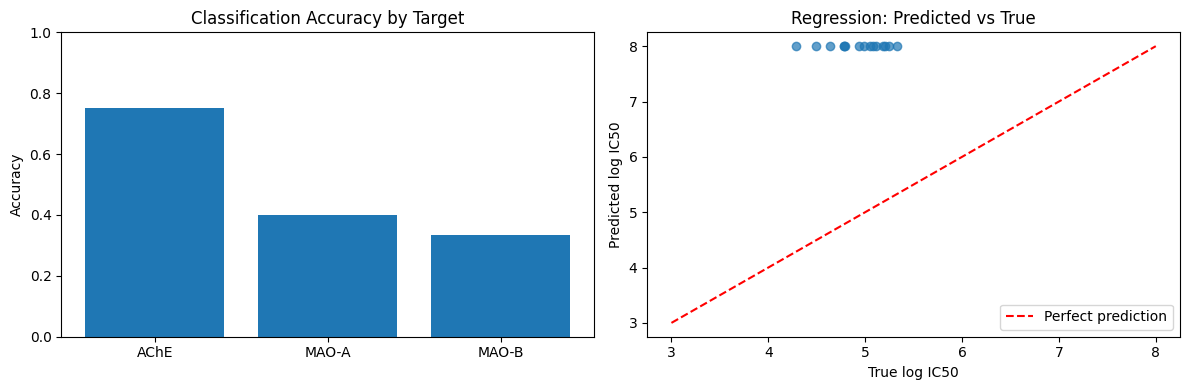

Visualization complete!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(12, 4))


valid_cls = results_df.dropna(subset=['pred_class'])
if len(valid_cls) > 0:
    target_acc = valid_cls.groupby('target').apply(
        lambda x: accuracy_score(x['true_class'], x['pred_class'])
    )

    axes[0].bar(target_acc.index, target_acc.values)
    axes[0].set_title('Classification Accuracy by Target')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)


valid_reg = results_df.dropna(subset=['pred_reg'])
if len(valid_reg) > 0:
    axes[1].scatter(valid_reg['true_reg'], valid_reg['pred_reg'], alpha=0.7)
    axes[1].plot([3, 8], [3, 8], 'r--', label='Perfect prediction')
    axes[1].set_xlabel('True log IC50')
    axes[1].set_ylabel('Predicted log IC50')
    axes[1].set_title('Regression: Predicted vs True')
    axes[1].legend()

plt.tight_layout()
plt.show()

print("Visualization complete!")